# Homework 7

David Godovich  
4/24/2026

In [1]:
# I don't use colab but have a fork of the class repo
# Run this to set up colab file structure
# %cd /content
# !rm -rf MOL518-Intro-to-Data-Analysis

# !git clone https://github.com/dgodovich/MOL518-Intro-to-Data-Analysis.git
# %cd MOL518-Intro-to-Data-Analysis/Homework_7

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy.fft as fft
import scipy.ndimage as ndimage
import skimage
import cv2

# Problem 1

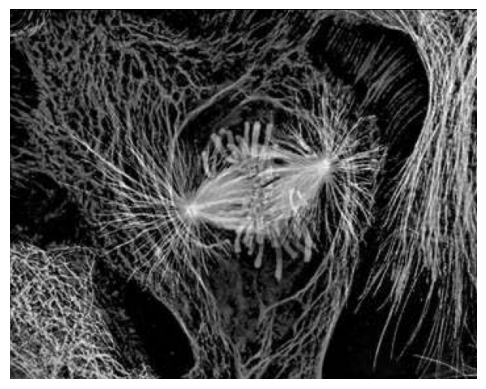

In [3]:
# a
microscopy = plt.imread('../Lecture_33/media/microscopy_example.png')
microscopy = skimage.color.rgb2gray(skimage.color.rgba2rgb(microscopy)) #it's an rgba image and I don't see a one function conversion to grayscale
plt.imshow(microscopy, cmap = 'gray')
plt.axis('off')
plt.show()

In [4]:
# b
shape = microscopy.shape
print('Array shape: ',shape)
print('Array data type: ',microscopy.dtype)
print(f'Image height: {shape[0]}; Image width: {shape[1]}')
print('Total pixels: ', shape[0]*shape[1])
print('Minimum Intensity: ', np.min(microscopy))
print('Maximum Intensity: ', np.max(microscopy))

Array shape:  (456, 576)
Array data type:  float32
Image height: 456; Image width: 576
Total pixels:  262656
Minimum Intensity:  0.0
Maximum Intensity:  0.9529411


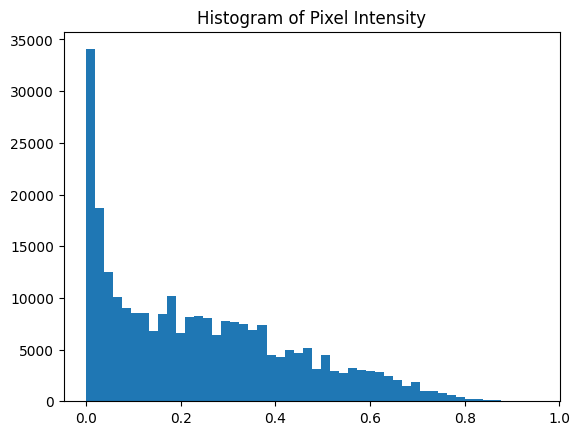

In [5]:
# c
plt.hist(microscopy.ravel(), bins = 50)
plt.title('Histogram of Pixel Intensity')
plt.show()

Most of the pixels in the image are dark (intensity == 0). The distribution is fairly broad and extends most of the way to bright pixel values (intensity == 1). I think the image is a bit "underexposed" and does not use the full dynamic range of the detector.

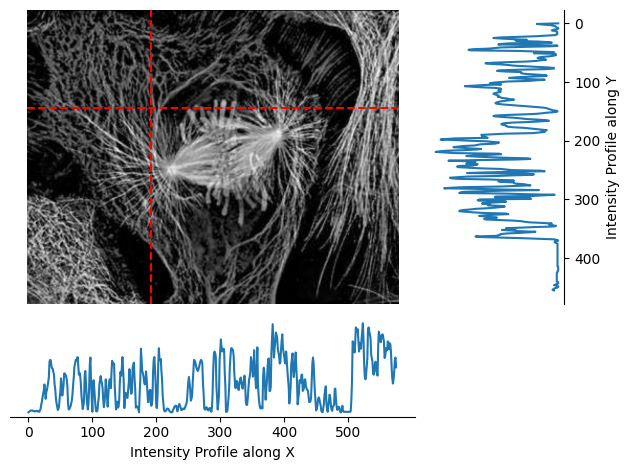

In [6]:
# d
shape = microscopy.shape
vertical = shape[1]//3
horizontal = shape[0]//3

vertical_projection = microscopy[:,vertical]
horizontal_projection = microscopy[horizontal,:]

fig, axes = plt.subplots(2,2, gridspec_kw = {'height_ratios': [3,1], 'width_ratios':[3,1]})
axes[0,0].imshow(microscopy, cmap = 'gray')
axes[0,0].axvline(vertical, c = 'r', ls = '--')
axes[0,0].axhline(horizontal, c = 'r', ls = '--')
axes[0,0].axis('off')

axes[1,0].plot(horizontal_projection)
axes[1,0].yaxis.set_visible(False)
axes[1,0].spines[['top', 'left', 'right']].set_visible(False)
axes[1,0].set_xticks(range(0,shape[1],100))
axes[1,0].set_xlabel('Intensity Profile along X')

axes[0,1].plot(vertical_projection, range(shape[0])) # plot rotated to look nicer
axes[0,1].xaxis.set_visible(False)
axes[0,1].invert_xaxis() # right align to look nicer
axes[0,1].invert_yaxis()
axes[0,1].spines[['top', 'bottom', 'left']].set_visible(False)
axes[0,1].set_yticks(range(0,shape[0],100))
axes[0,1].yaxis.tick_right()
axes[0,1].set_ylabel('Intensity Profile along Y')
axes[0,1].yaxis.set_label_position("right")

axes[1,1].axis('off')

plt.tight_layout()
plt.show()

I used a line 1/3 of the way through the image for both X and Y. In the X intensity plot, we can see a dark space and then an area of high frequency, high signal on the right side of the image, which corresponds to the bundle on the right side. The highest intensity region in the middle is going through the spindle in the dividing cell.  

In the Y intensity plot, there is a region of relatively uniform intensity around 100 pixels that happens as the line goes along a fiber. There is also a high frequency high intensity area as it goes through the spindle assembly. At the bottom of the image, there is an area of uniform low intensity that corresponds to a dark region of the image.

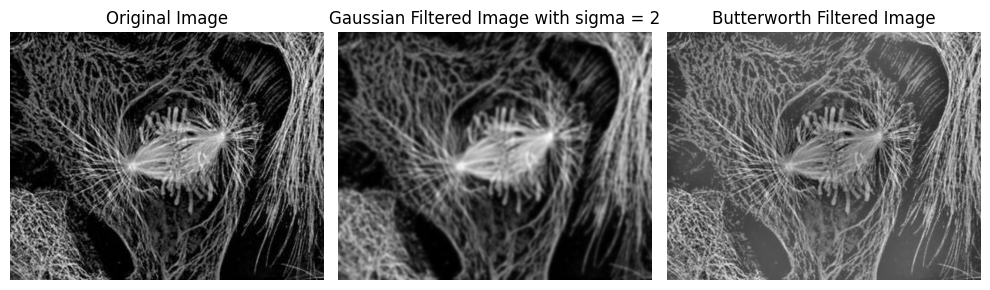

In [16]:
# e

gaussian_filter = skimage.filters.gaussian(microscopy, sigma = 2)
butterworth_filter = skimage.filters.butterworth(microscopy)

fig, axes = plt.subplots(1,3, figsize = (10,6))
axes[0].imshow(microscopy, cmap = 'gray')
axes[0].set_axis_off()
axes[0].set_title('Original Image')

axes[1].imshow(gaussian_filter, cmap = 'gray')
axes[1].set_axis_off()
axes[1].set_title('Gaussian Filtered Image with sigma = 2')

axes[2].imshow(butterworth_filter, cmap = 'gray')
axes[2].set_axis_off()
axes[2].set_title('Butterworth Filtered Image')

plt.tight_layout()
plt.show()

The Gaussian filter blurred the entire image in a uniform way. The Butterworth filter is a high pass frequency filter and enhances the visibility of high frequency objects. This is visible in the bottom right corner of the image, where the bottom of the fibers is more visible in the filtered image. I think the Butterworth filter could be more useful with some additional fine tuning to more precisely get objects of interest. 

# Problem 2

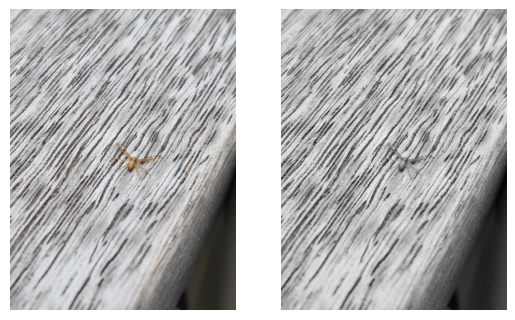

In [8]:
# a
spider = plt.imread('spider_on_table.jpg')
spider = np.rot90(spider, k = -1) # image was rotated

spider_gray = skimage.color.rgb2gray(spider)

fig, axes = plt.subplots(1,2)
axes[0].imshow(spider)
axes[0].axis('off')
axes[1].imshow(spider_gray, cmap = 'gray')
axes[1].axis('off')
plt.show()

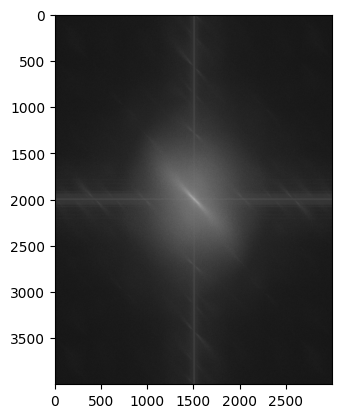

In [9]:
# b
fft2 = np.fft.fftshift(np.fft.fft2(spider_gray))
power_spectrum = np.log1p(np.abs(fft2))
plt.imshow(power_spectrum, cmap='gray');

In [10]:
# c, d
rows, cols = fft2.shape
yy, xx = np.ogrid[:rows, :cols]
cy, cx = rows // 2, cols // 2 
radius = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

low_pass_mask = radius <= 30
high_pass_mask = radius >= 50

low_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * low_pass_mask)).real
high_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * high_pass_mask)).real

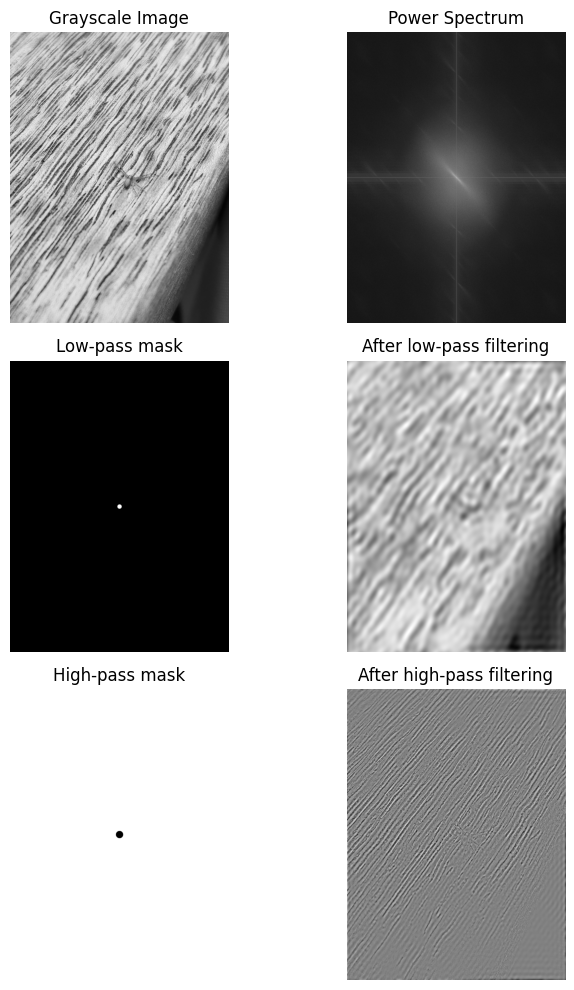

In [11]:
# e
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes[0, 0].imshow(spider_gray, cmap = 'gray')
axes[0, 0].set_title('Grayscale Image')
axes[0, 1].imshow(power_spectrum, cmap = 'gray')
axes[0, 1].set_title('Power Spectrum')
axes[1, 0].imshow(low_pass_mask, cmap='gray')
axes[1, 0].set_title('Low-pass mask')
axes[1, 1].imshow(low_pass_image, cmap='gray')
axes[1, 1].set_title('After low-pass filtering')
axes[2, 0].imshow(high_pass_mask, cmap='gray')
axes[2, 0].set_title('High-pass mask')
axes[2, 1].imshow(high_pass_image, cmap='gray')
axes[2, 1].set_title('After high-pass filtering')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()

The high pass filter preserves the lines of the wood on the table and some details about the spiders legs. The low pass filter is mostly a blurred image, but you can see the edge of the table and regions that don't have a wood pattern. You can also see the body of the spider, but the legs are moslty not visible.

# Problem 3

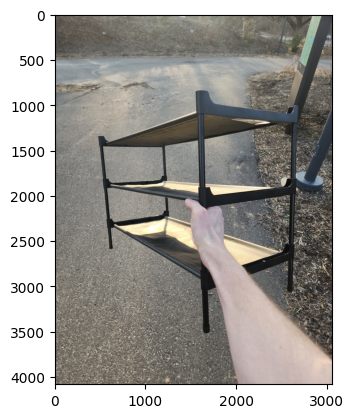

In [12]:
shoerack = plt.imread('shoerack.jpg')
shoerack = np.rot90(shoerack, k = -1)

plt.imshow(shoerack)
# plt.axis('off')
plt.show()

#### a  
My goal is to isolate the foreground from the background of this image and segment out the shoerack and if possible my hand.  
This idea came from being able to make a sticker out of it on my phone - that uses a fancy ML model which I won't be making, but I will try with simple processing techniques.

In [13]:
# b
# shoerack = plt.imread('shoerack.jpg')
# shoerack = np.rot90(shoerack, k = -1)
downsampled_shoe = shoerack[::5,::5] # decimate to make the image easier to work with
shoerack_gray = skimage.color.rgb2gray(downsampled_shoe) # grayscale
sobel = skimage.filters.sobel(shoerack_gray) # sobel filter because I want to use a watershed segmentation

thresh = skimage.filters.threshold_yen(shoerack_gray) # I found that Yen thresholding worked the best
gray_std = np.std(shoerack_gray) # for setting values to seed watershed

markers = np.zeros_like(shoerack_gray, dtype = 'uint8')
foreground, background = 1, 2
markers[shoerack_gray > (thresh + gray_std)] = background # bright areas are not the shoe rack
markers[shoerack_gray > (thresh + 3*gray_std)] = foreground # this gets the highlights on the shoerack
markers[shoerack_gray < (thresh - 1.5*gray_std)] = foreground # want the dark parts of the image

ws = skimage.segmentation.watershed(sobel, markers)

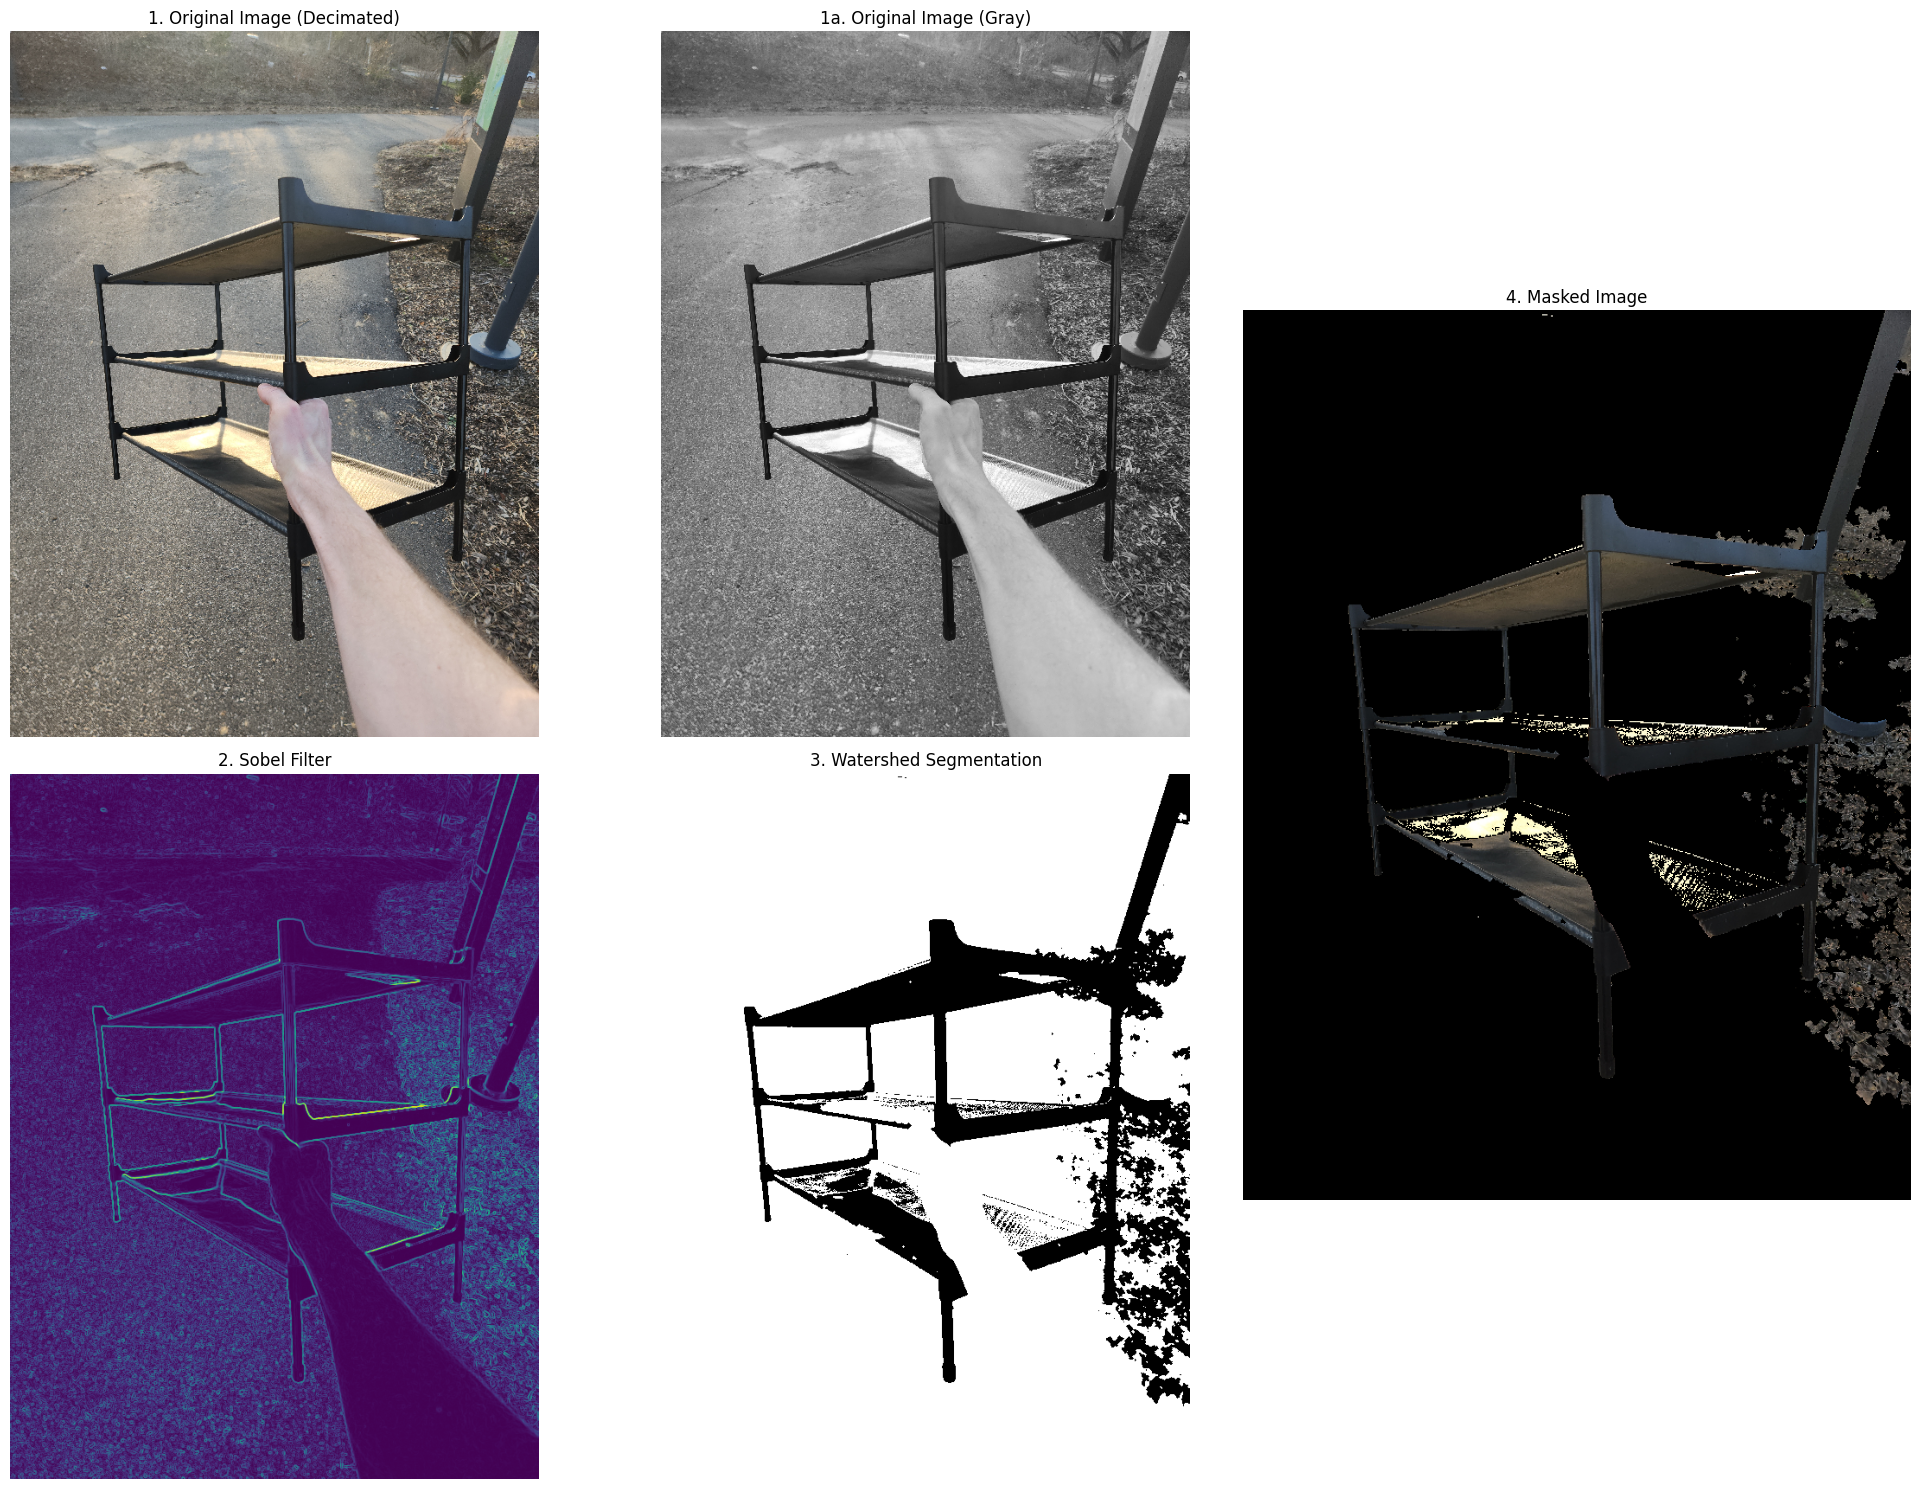

In [14]:
# c
def format_axes(fig):
    for i, ax in enumerate(fig.axes):
        ax.set_axis_off()
        
fig = plt.figure(figsize = (20,15), layout = 'tight')
gs = GridSpec(2,3, figure = fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[:, 2])

ax1.imshow(downsampled_shoe)
ax1.set_title('1. Original Image (Decimated)')
ax2.imshow(shoerack_gray, cmap = 'gray')
ax2.set_title('1a. Original Image (Gray)')
ax3.imshow(sobel)
ax3.set_title('2. Sobel Filter')
ax4.imshow(ws, cmap = 'gray')
ax4.set_title('3. Watershed Segmentation')

ax5.imshow(downsampled_shoe * np.expand_dims(ws == 1, axis = 2))
ax5.set_title('4. Masked Image')

format_axes(fig)
plt.show()

#### d, e  
To try to segment the shoe rack, I used a watershed segmentation approach. To do this I applied a series of processing steps to the image. I first used a Sobel filter to find edges, since watershed methods try to stay within edge boundaries. I then use a thresholding tool (Yen thresholding) to get a value I could use to estimate the background and foreground of the image. I used this threshold to define points that were 1.5 standard deviations below or 3 standard deviations above the threshold as my foreground. Here I was trying to capture the highlights on the shoerack shelves and the body of the shoerack.  

The final segmentation result is pretty bad. I wasn't able to get my hand in the same mask, since the intensity value are totally different (much brighter than the shoerack). The segmentation also got a lot of the ground and the pole since the sobel filter didn't find a strong edge in that area of the image. Another issue is artifacts in the highlights caused by the decimation, so maybe skipping that would have been better. I could improve this by trying a different segmentation technique like random walk segmentation, or seeing if filtering in Fourier space helps to remove some of the artifacts and ground.

#### figures from testing

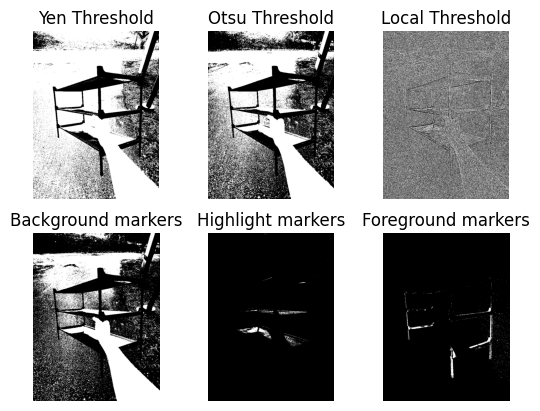

In [15]:
fig, axes = plt.subplots(2, 3)
yen_thresh = skimage.filters.threshold_yen(shoerack_gray)
otsu_thresh = skimage.filters.threshold_otsu(shoerack_gray)
local_thresh = skimage.filters.threshold_local(shoerack_gray)

axes[0][0].imshow(shoerack_gray > yen_thresh, cmap = 'gray')
axes[0][0].set_title('Yen Threshold')
axes[0][1].imshow(shoerack_gray > otsu_thresh, cmap = 'gray')
axes[0][1].set_title('Otsu Threshold')
axes[0][2].imshow(shoerack_gray > local_thresh, cmap = 'gray')
axes[0][2].set_title('Local Threshold')

gray_std = np.std(shoerack_gray)
axes[1][0].imshow(shoerack_gray > (yen_thresh + gray_std), cmap = 'gray')
axes[1][0].set_title('Background markers')
axes[1][1].imshow(shoerack_gray > (yen_thresh + 3*gray_std), cmap = 'gray')
axes[1][1].set_title('Highlight markers')
axes[1][2].imshow(shoerack_gray < (yen_thresh - 1.5*gray_std), cmap = 'gray')
axes[1][2].set_title('Foreground markers')

for ax in axes.flatten():
    ax.set_axis_off()